In [54]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from pathlib import Path
import torch
import torch.nn.functional as F
from datasets import load_dataset, Dataset, DatasetDict
from typing import List, Dict, Any

from transformers import AutoModel, AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

In [ ]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "boltuix/bert-emotion"
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model = model.to(device)
batch_size = 32
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Loading weights:   0%|          | 0/73 [00:00<?, ?it/s]

In [16]:
dataset = load_dataset("emotion")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [17]:
print("=== emotion - num table ===")
print(pd.DataFrame( dataset["train"].features["label"].names))
print('=== split sizes ===')
print(f'Train size:\n  {dataset['train'].shape}')
print(f'Val size:\n  {dataset['validation'].shape}')
print(f'Test size:\n  {dataset['test'].shape}')

=== emotion - num table ===
          0
0   sadness
1       joy
2      love
3     anger
4      fear
5  surprise
=== split sizes ===
Train size:
  (16000, 2)
Val size:
  (2000, 2)
Test size:
  (2000, 2)


In [18]:
print("=== train exaples ===")
print(pd.DataFrame(dataset["train"][:5]))
print("=== val exaples ===")
print(pd.DataFrame(dataset["validation"][:5]))
print("=== test exaples ===")
print(pd.DataFrame(dataset["test"][:5]))

=== train exaples ===
                                                                                                           text  label
0                                                                                       i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake      0
2                                                              im grabbing a minute to post i feel greedy wrong      3
3                  i am ever feeling nostalgic about the fireplace i will know that it is still on the property      2
4                                                                                          i am feeling grouchy      3
=== val exaples ===
                                                                     text  label
0   im feeling quite sad and sorry for myself but ill snap out of it soon      0
1  i feel like i am still looking at a blank canvas blank pieces of paper      0
2

В данном ноутбуке проводится обучение модели для классификация текстов по эмоциям. Модель должна научиться по ключевым словам понимать, какую эмоцию имел в виду автор.

In [19]:
def batch_tokenization_without_trunc(batch):
    return tokenizer(
        batch["text"],
        padding=True,
    )

tokenized_datasets = dataset.map(batch_tokenization_without_trunc, batched=True)

tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [20]:
example = tokenized_datasets["train"]

print('примеры токенизации без truncation')

for i in range(3):
    print(f"\n{'='*50}")
    print(f"Пример {i}:")
    print(f"label: {example['label'][i]}")
    print(f"input_ids: {example['input_ids'][i]}")
    print(f"attention_mask: {example['attention_mask'][i]}")
    
    #токены в текстовом виде
    tokens = tokenizer.convert_ids_to_tokens(example["input_ids"][i])
    print(f"Токены: {tokens}")
    
    print("Декодированный текст:")
    print(tokenizer.decode(example["input_ids"][i]))

примеры токенизации без truncation

Пример 0:
label: 0
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[

In [43]:
def batch_tokenization_with_trunc(batch):
    return tokenizer(
        batch["text"],
        padding=True,
        truncation=True,
        max_length= 70,
        return_tensors="pt",
    )

tokenized_datasets_with_trunc = dataset.map(batch_tokenization_with_trunc, batched=True)

tokenized_datasets_with_trunc = tokenized_datasets_with_trunc.remove_columns(["text"])
example_with_trunc = tokenized_datasets_with_trunc["train"]

print('примеры токенизации с truncation')
with open(ARTIFACTS_DIR/'tokenization_examples.txt', 'w', encoding='utf-8') as file:
    for i in range(5):
        print(f"\n{'='*50}")
        print(f"Пример {i}:")
        print(f"label: {example_with_trunc['label'][i]}")
        print(f"input_ids: {example_with_trunc['input_ids'][i]}")
        print(f"attention_mask: {example_with_trunc['attention_mask'][i]}")
    
        #токены в текстовом виде
        tokens = tokenizer.convert_ids_to_tokens(example_with_trunc["input_ids"][i])
        print(f"Токены: {tokens}")
    
        print("Декодированный текст:")
        print(tokenizer.decode(example_with_trunc["input_ids"][i]))
 
        file.write(f'Examples: \n {tokens}')

примеры токенизации с truncation

Пример 0:
label: 0
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PA

In [62]:
text_examples = dataset['train']['text'][:5]
def predict_many_texts(texts: List[str], model) -> pd.DataFrame:
    encoded = batch_tokenization_with_trunc({'text': texts})
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)

    probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()
    pred_ids = probs.argmax(axis=1)

    rows = []
    for text, pred_id, prob_row in zip(texts, pred_ids, probs):
        pred_label = model.config.id2label[int(pred_id)]
        pred_score = float(prob_row[int(pred_id)])
        row = {
            "text": text,
            "pred_label": pred_label,
        }
        rows.append(row)

    return pd.DataFrame(rows)

inference_examples = predict_many_texts(text_examples, model)
label_names = dataset['train'].features['label'].names
true_labels_numeric = dataset['train']['label'][:5]
true_labels_text = [label_names[idx] for idx in true_labels_numeric]

inference_examples['true_label'] = true_labels_text

inference_examples['correct'] = inference_examples['pred_label'] == inference_examples['true_label']

print(inference_examples)

                                                                                                           text pred_label true_label  correct
0                                                                                       i didnt feel humiliated    sadness    sadness     True
1  i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake    sadness    sadness     True
2                                                              im grabbing a minute to post i feel greedy wrong   surprise      anger    False
3                  i am ever feeling nostalgic about the fireplace i will know that it is still on the property       love       love     True
4                                                                                          i am feeling grouchy   surprise      anger    False


Итого на 5 примерах видно, что модель предсказывает правильно не все. Для задачи тяжело сделать вывод подходит ли в сыром виде, потому что в данном примере слишком мало данных. Переходим к fine-tuning, чтобы уличшить качество нашей модели.

In [23]:
print(tokenized_datasets_with_trunc) #ранее все данные токенизировали

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [24]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

input_ids: shape=(3, 70)
token_type_ids: shape=(3, 70)
attention_mask: shape=(3, 70)
labels: shape=(3,)


In [25]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

In [26]:
common_training_kwargs = dict(
    output_dir="outputs/s13_bert_finetuning_demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [27]:
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.064406,0.135218,0.948500,0.925679,0.949001
2,0.093196,0.133355,0.955000,0.932488,0.954769
3,0.000889,0.136764,0.955000,0.935689,0.955256
4,0.016519,0.157933,0.955500,0.936308,0.955628
5,0.000930,0.156991,0.954000,0.932851,0.953980


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias'].
There were unexpected keys in the checkp

TrainOutput(global_step=10000, training_loss=0.13939159054557093, metrics={'train_runtime': 172.7444, 'train_samples_per_second': 463.112, 'train_steps_per_second': 57.889, 'total_flos': 123868990785120.0, 'train_loss': 0.13939159054557093, 'epoch': 5.0})

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,2.9678,12.5348,1.9998e-05,0.001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.4072,20.2452,1.9994e-05,0.002,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.3904,20.6448,1.9990e-05,0.003,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.3805,23.8264,1.9986e-05,0.004,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.7257,19.4214,1.9982e-05,0.005,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.8932,13.7427,1.9978e-05,0.006,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2.1036,17.0752,1.9974e-05,0.007,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2.3150,21.2412,1.9970e-05,0.008,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2.5455,21.5622,1.9966e-05,0.009,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.7550,28.0808,1.9962e-05,0.010,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


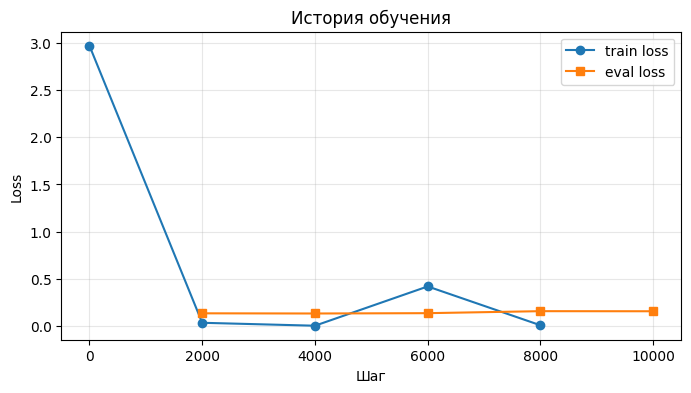

In [31]:
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"][::1000], train_logs["loss"][::1000], marker="o", label="train loss") #масштабируем

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(FIGURES_DIR/'training_curves.png')
plt.show()

Classification report on test:
              precision    recall  f1-score   support

     sadness       0.97      0.98      0.98       581
         joy       0.97      0.96      0.96       695
        love       0.86      0.89      0.88       159
       anger       0.97      0.94      0.95       275
        fear       0.93      0.94      0.94       224
    surprise       0.84      0.85      0.84        66

    accuracy                           0.95      2000
   macro avg       0.92      0.93      0.92      2000
weighted avg       0.95      0.95      0.95      2000



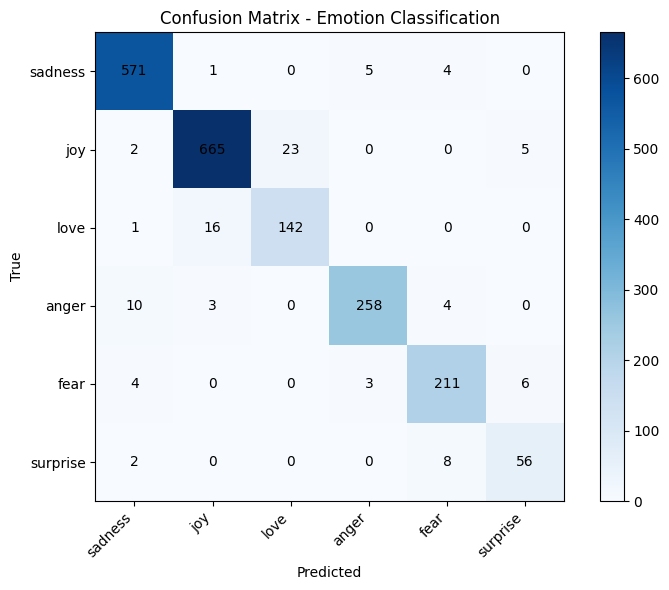

In [61]:
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids
label_names = dataset["train"].features["label"].names


print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=label_names,  
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)


fig, ax = plt.subplots(figsize=(8, 6)) 
im = ax.imshow(cm, cmap='Blues')


ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix - Emotion Classification")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=10)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR/'confusion_matrix.png')
plt.show()

In [ ]:
test_output = trainer.predict(tokenized_datasets["test"])
test_preds = np.argmax(test_output.predictions, axis=-1)
test_true = test_output.label_ids

label_names = dataset["train"].features["label"].names

results_df = pd.DataFrame({
    'text': dataset['test']['text'],
    'true_label': [label_names[i] for i in test_true],
    'pred_label': [label_names[i] for i in test_preds],
    'correct': test_preds == test_true
})

probs = F.softmax(torch.tensor(test_output.predictions), dim=-1).numpy()
results_df['confidence'] = [probs[i][test_preds[i]] for i in range(len(test_preds))]
results_df[results_df['correct'] == False] #просмотр ошибочных предсказаний

,text,true_label,pred_label,correct,confidence
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have be...,joy,love,False,0.8201
67,i feel a bit stressed even though all the things i have going on are fun,anger,sadness,False,0.9765
86,i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love,joy,love,False,0.9637
93,i was feeling weird the other day and it went away about minutes after i took my metformin,fear,surprise,False,0.6042
96,i love neglecting this blog but sometimes i feel for my faithful readers,love,joy,False,0.7580
...,...,...,...,...,...
1911,im ok with that it feels a little weird,surprise,fear,False,0.6651
1928,i feel inside cause life is like a game sometimes but then you came around me the walls just disappeared nothing to surround me and keep...,fear,sadness,False,0.9919
1943,i didn t mean to get angry with you bommie i just can t control my feelings hellip i just hated myself why i am like this the dara who c...,sadness,anger,False,0.4970
1956,i was gaining weight getting a lot stronger and feeling amazing,joy,surprise,False,0.8944


In [70]:
results_df.to_csv(ARTIFACTS_DIR/'sample_predictions.csv', index=False, encoding='utf-8-sig')